In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Загрузка данных
df = pd.read_csv('final_dataset_with_clusters.csv')

# Проверка
print("=== Проверка данных ===")
print(f"Размер: {df.shape}")
print(f"\nКолонки:\n{df.columns.tolist()}")
print(f"\nТипы данных:\n{df.dtypes}")

# Числовые признаки для анализа (без ID и меток кластеров)
features = ['duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load']
df_features = df[features].copy()

print(f"\n--- Признаки для анализа: {features} ---")
print(df_features.describe())

# Создание отдельных датасетов для каждого кластера (для K-Means)
print("\n=== Создание датасетов по кластерам K-Means ===")
clusters_kmeans = sorted(df['cluster_kmeans'].unique())
datasets_by_cluster = {}
for cluster in clusters_kmeans:
    datasets_by_cluster[cluster] = df[df['cluster_kmeans'] == cluster][features]
    print(f"Кластер {cluster}: {len(datasets_by_cluster[cluster])} записей")

=== Проверка данных ===
Размер: (500, 11)

Колонки:
['measurement_id', 'timestamp', 'operation_name', 'duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load', 'cluster_kmeans', 'cluster_dbscan', 'cluster_hierarchical']

Типы данных:
measurement_id            int64
timestamp                   str
operation_name              str
duration_ms             float64
data_size                 int64
n_queries                 int64
is_peak_hour              int64
server_load             float64
cluster_kmeans            int64
cluster_dbscan            int64
cluster_hierarchical      int64
dtype: object

--- Признаки для анализа: ['duration_ms', 'data_size', 'n_queries', 'is_peak_hour', 'server_load'] ---
       duration_ms   data_size   n_queries  is_peak_hour  server_load
count   500.000000  500.000000  500.000000    500.000000   500.000000
mean    404.128700  229.800000  118.222000      0.502000     0.506316
std     382.345923  160.166371  159.491127      0.500497     0.222916
mi

In [4]:
# Корреляционная матрица Пирсона
corr_pearson = df_features.corr(method='pearson')

print("\n=== КОРРЕЛЯЦИОННАЯ МАТРИЦА ПИРСОНА ===")
print(corr_pearson.round(3))

# Сохраним для отчета
corr_pearson.to_csv('corr_pearson.csv')
print("\nМатрица сохранена в 'corr_pearson.csv'")


=== КОРРЕЛЯЦИОННАЯ МАТРИЦА ПИРСОНА ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.194      0.862         0.139       -0.048
data_size           0.194      1.000      0.484         0.094        0.055
n_queries           0.862      0.484      1.000         0.021       -0.010
is_peak_hour        0.139      0.094      0.021         1.000       -0.053
server_load        -0.048      0.055     -0.010        -0.053        1.000

Матрица сохранена в 'corr_pearson.csv'


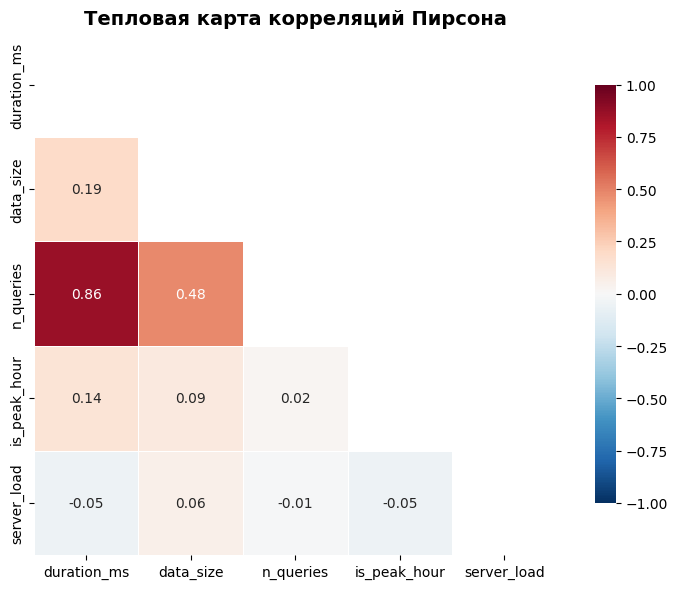

In [5]:
# Тепловая карта Пирсона
plt.figure(figsize=(8, 6))

# Маска для верхней треугольной части
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

# Тепловая карта
sns.heatmap(corr_pearson, 
            mask=mask, 
            annot=True,      
            fmt='.2f',       
            cmap='RdBu_r',   
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})

plt.title('Тепловая карта корреляций Пирсона', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_pearson.png', dpi=150, bbox_inches='tight')
plt.show()


=== КОРРЕЛЯЦИОННАЯ МАТРИЦА СПИРМЕНА ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.278      0.923         0.188       -0.049
data_size           0.278      1.000      0.263         0.097        0.050
n_queries           0.923      0.263      1.000        -0.007       -0.046
is_peak_hour        0.188      0.097     -0.007         1.000       -0.051
server_load        -0.049      0.050     -0.046        -0.051        1.000


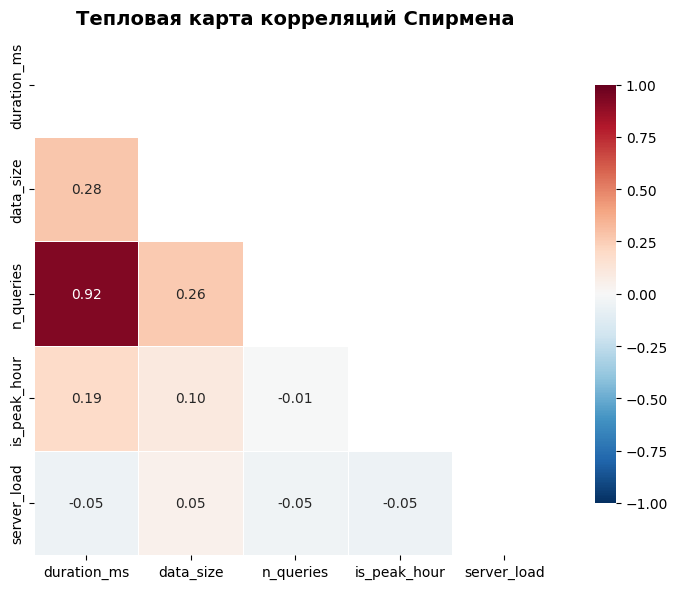


=== СРАВНЕНИЕ КОЭФФИЦИЕНТОВ ===
                          Пирсон  Спирмен  Разница
duration_ms—data_size      0.194    0.278    0.084
duration_ms—n_queries      0.862    0.923    0.061
duration_ms—is_peak_hour   0.139    0.188    0.049
duration_ms—server_load   -0.048   -0.049   -0.001
data_size—n_queries        0.484    0.263   -0.221
data_size—is_peak_hour     0.094    0.097    0.003
data_size—server_load      0.055    0.050   -0.005
n_queries—is_peak_hour     0.021   -0.007   -0.028
n_queries—server_load     -0.010   -0.046   -0.037
is_peak_hour—server_load  -0.053   -0.051    0.002


In [6]:
# Корреляционная матрица Спирмена
corr_spearman = df_features.corr(method='spearman')

print("\n=== КОРРЕЛЯЦИОННАЯ МАТРИЦА СПИРМЕНА ===")
print(corr_spearman.round(3))

# Тепловая карта Спирмена
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, 
            mask=mask, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляций Спирмена', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

# Сравнение Пирсона и Спирмена
print("\n=== СРАВНЕНИЕ КОЭФФИЦИЕНТОВ ===")
comparison = pd.DataFrame({
    'Пирсон': corr_pearson.values[np.triu_indices_from(corr_pearson, k=1)],
    'Спирмен': corr_spearman.values[np.triu_indices_from(corr_spearman, k=1)]
}, index=[f"{corr_pearson.index[i]}—{corr_pearson.columns[j]}" 
          for i,j in zip(*np.triu_indices_from(corr_pearson, k=1))])
comparison['Разница'] = comparison['Спирмен'] - comparison['Пирсон']
print(comparison.round(3))

In [7]:
# Расчет p-value
def get_corr_pvalues(df):
    cols = df.columns
    n_cols = len(cols)
    pvalues = np.zeros((n_cols, n_cols))
    for i in range(n_cols):
        for j in range(n_cols):
            if i == j:
                pvalues[i, j] = 0
            else:
                _, pvalues[i, j] = stats.pearsonr(df[cols[i]], df[cols[j]])
    return pd.DataFrame(pvalues, index=cols, columns=cols)

pvalues = get_corr_pvalues(df_features)

print("\n=== P-VALUE МАТРИЦА ===")
print(pvalues.round(6))

# Значимые корреляции (p < 0.05)
print("\n=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===")
significant_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        if pvalues.iloc[i, j] < 0.05:
            significant_pairs.append({
                'Признак 1': features[i],
                'Признак 2': features[j],
                'r Пирсона': corr_pearson.iloc[i, j],
                'p-value': pvalues.iloc[i, j]
            })
            print(f"{features[i]} — {features[j]}: r = {corr_pearson.iloc[i, j]:.3f}, p = {pvalues.iloc[i, j]:.6f}")

# Таблица 2 для отчета
df_table2 = pd.DataFrame(significant_pairs)
print("\n=== ТАБЛИЦА 2: ЗНАЧИМЫЕ КОРРЕЛЯЦИИ ===")
print(df_table2.to_string(index=False))


=== P-VALUE МАТРИЦА ===
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms      0.000000   0.000013   0.000000      0.001776     0.286726
data_size        0.000013   0.000000   0.000000      0.035121     0.218292
n_queries        0.000000   0.000000   0.000000      0.642351     0.832110
is_peak_hour     0.001776   0.035121   0.642351      0.000000     0.233073
server_load      0.286726   0.218292   0.832110      0.233073     0.000000

=== ЗНАЧИМЫЕ КОРРЕЛЯЦИИ (p < 0.05) ===
duration_ms — data_size: r = 0.194, p = 0.000013
duration_ms — n_queries: r = 0.862, p = 0.000000
duration_ms — is_peak_hour: r = 0.139, p = 0.001776
data_size — n_queries: r = 0.484, p = 0.000000
data_size — is_peak_hour: r = 0.094, p = 0.035121

=== ТАБЛИЦА 2: ЗНАЧИМЫЕ КОРРЕЛЯЦИИ ===
  Признак 1    Признак 2  r Пирсона       p-value
duration_ms    data_size   0.193967  1.254291e-05
duration_ms    n_queries   0.861988 4.799472e-149
duration_ms is_peak_hour   0.139434  1.776084e-0

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Расчет VIF
X = df_features.copy()
X = X.assign(const=1)

vif_data = pd.DataFrame()
vif_data['Признак'] = features
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]

print("\n=== ТАБЛИЦА 3. ЗНАЧЕНИЯ VIF ДЛЯ ВСЕХ ПРИЗНАКОВ ===")
print(vif_data.to_string(index=False))

# Детальная интерпретация
print("\n=== ИНТЕРПРЕТАЦИЯ ===")
high_vif = []
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        high_vif.append(row['Признак'])
        print(f"⚠️ {row['Признак']}: VIF = {row['VIF']:.2f} — КРИТИЧЕСКАЯ мультиколлинеарность")
    elif row['VIF'] > 5:
        high_vif.append(row['Признак'])
        print(f"⚡ {row['Признак']}: VIF = {row['VIF']:.2f} — ВЫСОКАЯ мультиколлинеарность")
    else:
        print(f"✅ {row['Признак']}: VIF = {row['VIF']:.2f} — проблем нет")

if high_vif:
    print(f"\n🔴 Проблемные признаки: {high_vif}")
    print("📌 Рекомендация: удалить один из сильно коррелирующих признаков (например, n_queries или duration_ms)")
else:
    print("\n🟢 Проблем мультиколлинеарности не обнаружено")


=== ТАБЛИЦА 3. ЗНАЧЕНИЯ VIF ДЛЯ ВСЕХ ПРИЗНАКОВ ===
     Признак      VIF
 duration_ms 5.879211
   data_size 1.879144
   n_queries 7.275809
is_peak_hour 1.139927
 server_load 1.009491

=== ИНТЕРПРЕТАЦИЯ ===
⚡ duration_ms: VIF = 5.88 — ВЫСОКАЯ мультиколлинеарность
✅ data_size: VIF = 1.88 — проблем нет
⚡ n_queries: VIF = 7.28 — ВЫСОКАЯ мультиколлинеарность
✅ is_peak_hour: VIF = 1.14 — проблем нет
✅ server_load: VIF = 1.01 — проблем нет

🔴 Проблемные признаки: ['duration_ms', 'n_queries']
📌 Рекомендация: удалить один из сильно коррелирующих признаков (например, n_queries или duration_ms)



=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ K-MEANS ===


--- КЛАСТЕР 0 (n=206) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.373      0.858         0.207       -0.070
data_size           0.373      1.000      0.239         0.092        0.035
n_queries           0.858      0.239      1.000         0.076       -0.077
is_peak_hour        0.207      0.092      0.076         1.000       -0.065
server_load        -0.070      0.035     -0.077        -0.065        1.000


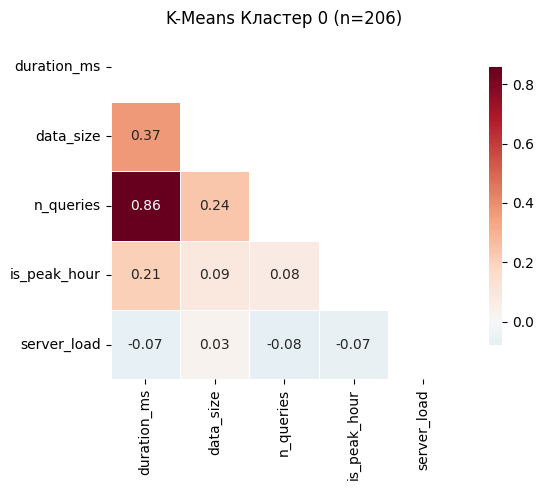


🔗 Сильные корреляции в кластере:
   duration_ms — n_queries: r = 0.858

--- КЛАСТЕР 1 (n=104) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.604      0.604         0.782        0.001
data_size           0.604      1.000      1.000         0.062        0.190
n_queries           0.604      1.000      1.000         0.062        0.190
is_peak_hour        0.782      0.062      0.062         1.000       -0.146
server_load         0.001      0.190      0.190        -0.146        1.000


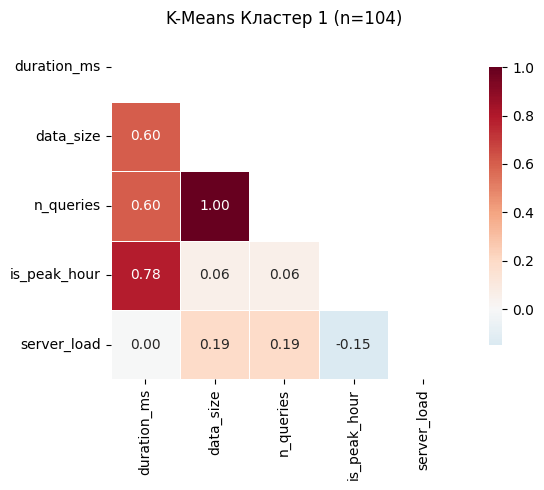


🔗 Сильные корреляции в кластере:
   duration_ms — data_size: r = 0.604
   duration_ms — n_queries: r = 0.604
   duration_ms — is_peak_hour: r = 0.782
   data_size — n_queries: r = 1.000

--- КЛАСТЕР 2 (n=190) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000     -0.311      0.743         0.241       -0.105
data_size          -0.311      1.000      0.123         0.100        0.104
n_queries           0.743      0.123      1.000        -0.017       -0.086
is_peak_hour        0.241      0.100     -0.017         1.000        0.010
server_load        -0.105      0.104     -0.086         0.010        1.000


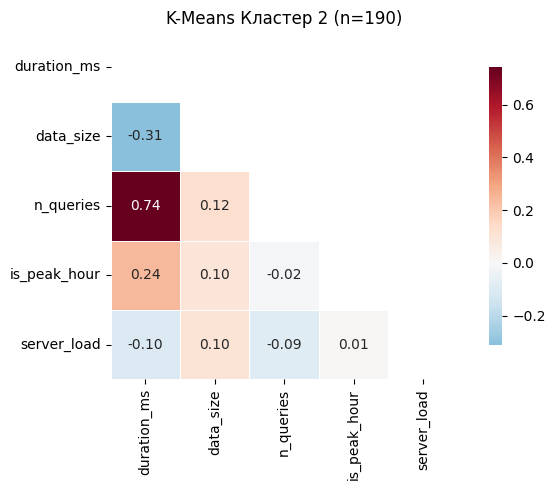


🔗 Сильные корреляции в кластере:
   duration_ms — n_queries: r = 0.743


In [9]:
# Внутрикластерный анализ для K-Means
print("\n=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ K-MEANS ===\n")

clusters_kmeans = sorted(df['cluster_kmeans'].unique())

for cluster in clusters_kmeans:
    print(f"\n--- КЛАСТЕР {cluster} (n={len(df[df['cluster_kmeans'] == cluster])}) ---")
    
    # Данные кластера
    cluster_data = df[df['cluster_kmeans'] == cluster][features]
    
    # Корреляционная матрица
    corr_cluster = cluster_data.corr(method='pearson')
    print("\nКорреляционная матрица Пирсона:")
    print(corr_cluster.round(3))
    
    # Тепловая карта
    plt.figure(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr_cluster, dtype=bool))
    sns.heatmap(corr_cluster, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, 
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(f'K-Means Кластер {cluster} (n={len(cluster_data)})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'heatmap_kmeans_cluster_{cluster}.png', dpi=150)
    plt.show()
    
    # Выделим сильные связи
    print("\n🔗 Сильные корреляции в кластере:")
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            r = corr_cluster.iloc[i, j]
            if abs(r) >= 0.5:
                print(f"   {features[i]} — {features[j]}: r = {r:.3f}")

In [10]:
# Внутрикластерный анализ для DBSCAN
print("\n=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ DBSCAN ===\n")

clusters_dbscan = sorted([c for c in df['cluster_dbscan'].unique() if c != -1])  # исключаем шум
print(f"Анализируемые кластеры DBSCAN (без шума): {clusters_dbscan}")

for cluster in clusters_dbscan:
    print(f"\n--- КЛАСТЕР DBSCAN {cluster} (n={len(df[df['cluster_dbscan'] == cluster])}) ---")
    
    cluster_data = df[df['cluster_dbscan'] == cluster][features]
    corr_cluster = cluster_data.corr(method='pearson')
    print("\nКорреляционная матрица Пирсона:")
    print(corr_cluster.round(3))
    
    # Сильные связи
    print("\n🔗 Сильные корреляции (|r| >= 0.5):")
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            r = corr_cluster.iloc[i, j]
            if abs(r) >= 0.5:
                print(f"   {features[i]} — {features[j]}: r = {r:.3f}")


=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ DBSCAN ===

Анализируемые кластеры DBSCAN (без шума): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- КЛАСТЕР DBSCAN 0 (n=112) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.371      0.893           NaN       -0.166
data_size           0.371      1.000      0.250           NaN        0.141
n_queries           0.893      0.250      1.000           NaN       -0.191
is_peak_hour          NaN        NaN        NaN           NaN          NaN
server_load        -0.166      0.141     -0.191           NaN        1.000

🔗 Сильные корреляции (|r| >= 0.5):
   duration_ms — n_queries: r = 0.893

--- КЛАСТЕР DBSCAN 1 (n=205) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.094      0.861           NaN       -0.071
data_size           0.094      1.000      0

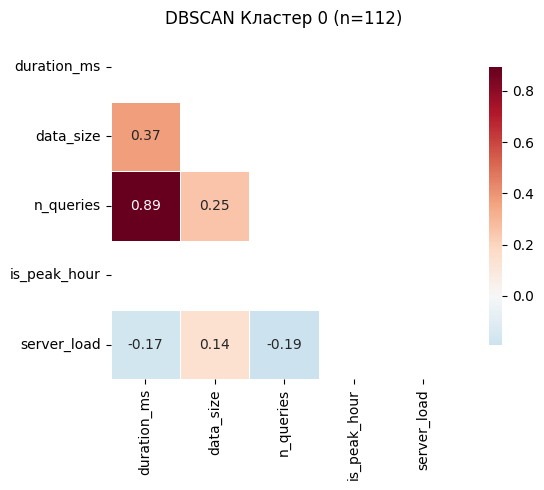

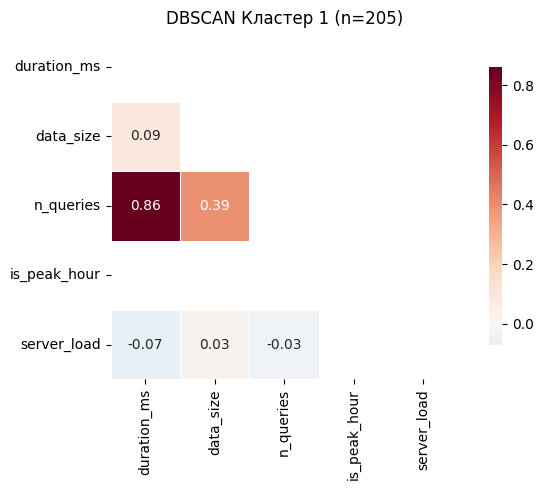

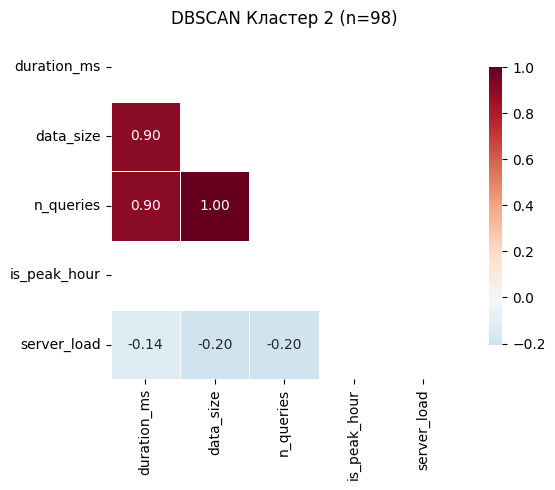

In [11]:
# Тепловые карты для DBSCAN (кластеры 0, 1, 2)
clusters_to_plot = [0, 1, 2]
titles = ['DBSCAN Кластер 0 (n=112)', 'DBSCAN Кластер 1 (n=205)', 'DBSCAN Кластер 2 (n=98)']

for cluster, title in zip(clusters_to_plot, titles):
    cluster_data = df[df['cluster_dbscan'] == cluster][features]
    corr_cluster = cluster_data.corr(method='pearson')
    
    plt.figure(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr_cluster, dtype=bool))
    sns.heatmap(corr_cluster, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, 
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'heatmap_dbscan_cluster_{cluster}.png', dpi=150)
    plt.show()


=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ HIERARCHICAL ===

Кластеры Hierarchical: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

--- КЛАСТЕР HIERARCHICAL 1 (n=219) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.165      0.934         0.095       -0.095
data_size           0.165      1.000      0.046         0.082        0.070
n_queries           0.934      0.046      1.000        -0.009       -0.091
is_peak_hour        0.095      0.082     -0.009         1.000        0.005
server_load        -0.095      0.070     -0.091         0.005        1.000

🔗 Сильные корреляции (|r| >= 0.5):
   duration_ms — n_queries: r = 0.934

--- КЛАСТЕР HIERARCHICAL 2 (n=53) ---

Корреляционная матрица Пирсона:
              duration_ms  data_size  n_queries  is_peak_hour  server_load
duration_ms         1.000      0.541      0.541         0.920       -0.068
data_size           0.541      1.000      1.000         0.

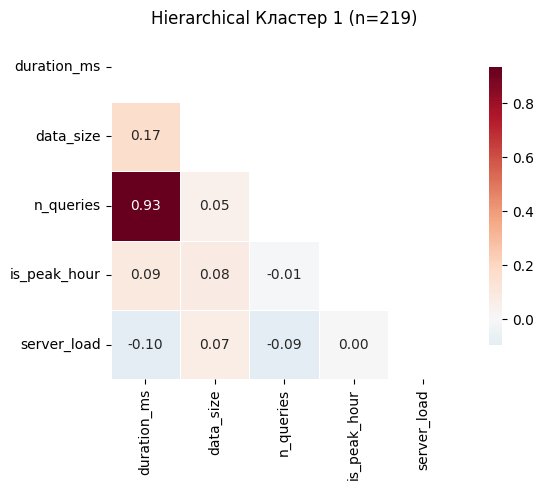

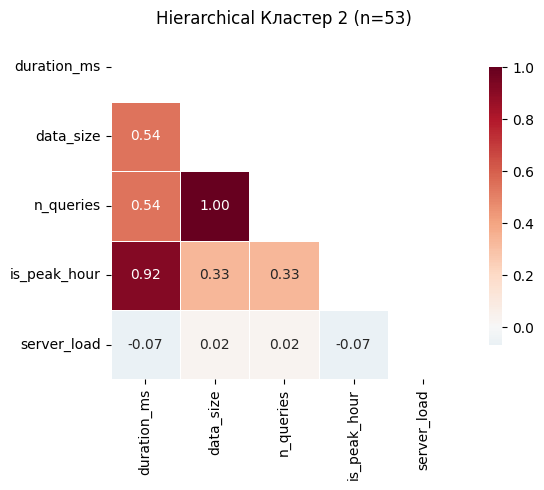

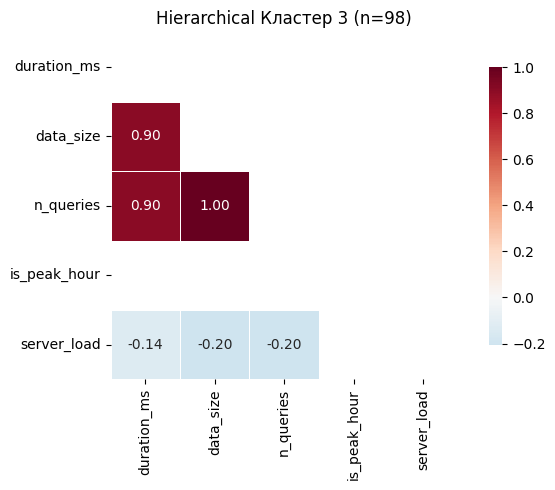

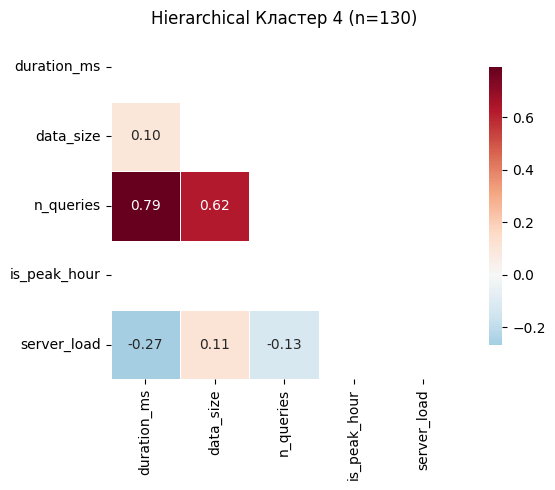

In [12]:
# Внутрикластерный анализ для Hierarchical
print("\n=== ВНУТРИКЛАСТЕРНЫЙ АНАЛИЗ HIERARCHICAL ===\n")

clusters_hier = sorted(df['cluster_hierarchical'].unique())
print(f"Кластеры Hierarchical: {clusters_hier}")

for cluster in clusters_hier:
    print(f"\n--- КЛАСТЕР HIERARCHICAL {cluster} (n={len(df[df['cluster_hierarchical'] == cluster])}) ---")
    
    cluster_data = df[df['cluster_hierarchical'] == cluster][features]
    corr_cluster = cluster_data.corr(method='pearson')
    print("\nКорреляционная матрица Пирсона:")
    print(corr_cluster.round(3))
    
    # Сильные корреляции
    print("\n🔗 Сильные корреляции (|r| >= 0.5):")
    has_strong = False
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            r = corr_cluster.iloc[i, j]
            if abs(r) >= 0.5:
                print(f"   {features[i]} — {features[j]}: r = {r:.3f}")
                has_strong = True
    if not has_strong:
        print("   (нет сильных корреляций)")

# Тепловые карты для Hierarchical
print("\n=== ГЕНЕРАЦИЯ ТЕПЛОВЫХ КАРТ ДЛЯ ОТЧЕТА ===\n")

for cluster in clusters_hier:
    cluster_data = df[df['cluster_hierarchical'] == cluster][features]
    corr_cluster = cluster_data.corr(method='pearson')
    
    plt.figure(figsize=(7, 5))
    mask = np.triu(np.ones_like(corr_cluster, dtype=bool))
    sns.heatmap(corr_cluster, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, 
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title(f'Hierarchical Кластер {cluster} (n={len(cluster_data)})', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'heatmap_hierarchical_cluster_{cluster}.png', dpi=150)
    plt.show()


=== ТАБЛИЦА 7. СВОДНЫЕ МЕТРИКИ ОДНОРОДНОСТИ КЛАСТЕРОВ ===


K-Means:
----------------------------------------------------------------------
Кластер    Размер     Признаков  Ср. сила корр.  Стд. отклонение Сильных связей 
----------------------------------------------------------------------
0          206        5          0.209          0.238           1
1          104        5          0.364          0.334           2
2          190        5          0.184          0.206           1
----------------------------------------------------------------------

DBSCAN:
----------------------------------------------------------------------
Кластер    Размер     Признаков  Ср. сила корр.  Стд. отклонение Сильных связей 
----------------------------------------------------------------------
0          112        4          0.335          0.260           1
1          205        4          0.247          0.302           1
2          98         4          0.559          0.379           3
3       

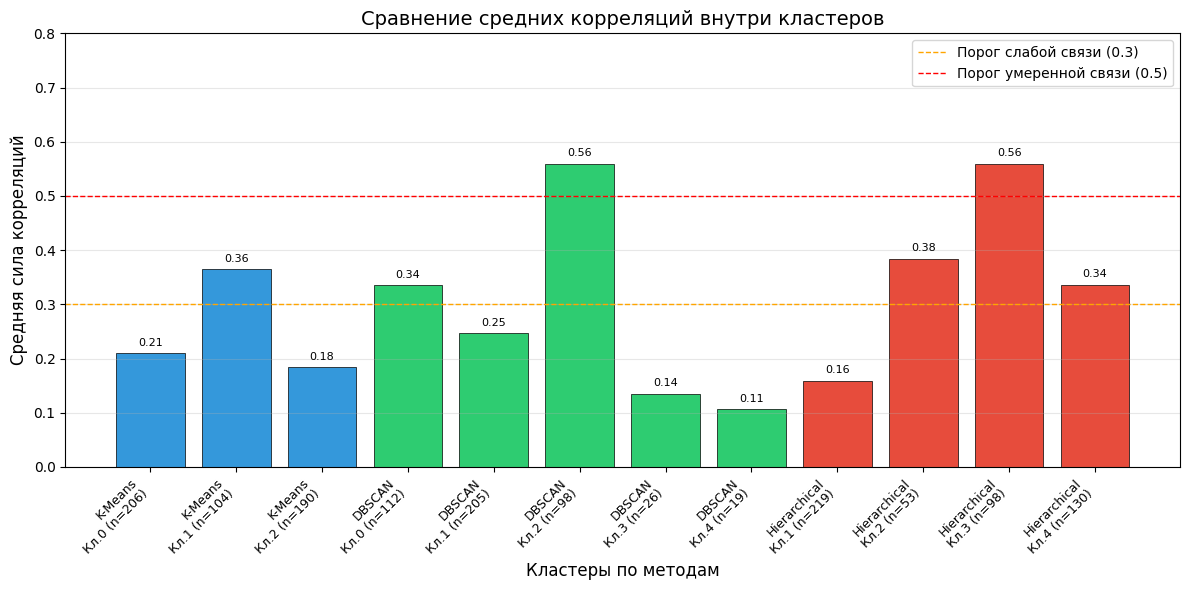


📊 График сохранен как 'comparison_avg_correlations.png'


In [13]:
# Исправленная функция для расчета метрик (игнорируем константные признаки)
def cluster_homogeneity_metrics_fixed(df, cluster_col, features):
    """Рассчитывает метрики однородности, игнорируя константные признаки"""
    clusters = sorted([c for c in df[cluster_col].unique() if c != -1])
    results = []
    
    for c in clusters:
        cluster_data = df[df[cluster_col] == c][features]
        n = len(cluster_data)
        
        # Удаляем константные признаки (с нулевой дисперсией)
        non_const_features = []
        for feat in features:
            if cluster_data[feat].std() > 0:
                non_const_features.append(feat)
        
        if len(non_const_features) < 2:
            results.append({
                'cluster': c,
                'size': n,
                'avg_corr': 0,
                'std_corr': 0,
                'strong_corr': 0,
                'features_used': len(non_const_features)
            })
            continue
        
        # Корреляционная матрица только для неконстантных признаков
        corr = cluster_data[non_const_features].corr().values
        
        # Верхний треугольник без диагонали
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        if np.sum(mask) > 0:
            avg_corr = np.mean(np.abs(corr[mask]))
            std_corr = np.std(np.abs(corr[mask]))
            strong_count = np.sum(np.abs(corr[mask]) >= 0.7)
        else:
            avg_corr = 0
            std_corr = 0
            strong_count = 0
        
        results.append({
            'cluster': c,
            'size': n,
            'avg_corr': avg_corr,
            'std_corr': std_corr,
            'strong_corr': strong_count,
            'features_used': len(non_const_features)
        })
    
    return results

# Расчет метрик
print("\n=== ТАБЛИЦА 7. СВОДНЫЕ МЕТРИКИ ОДНОРОДНОСТИ КЛАСТЕРОВ ===\n")

methods = [
    ('K-Means', 'cluster_kmeans'),
    ('DBSCAN', 'cluster_dbscan'),
    ('Hierarchical', 'cluster_hierarchical')
]

all_results = {}

for method_name, cluster_col in methods:
    results = cluster_homogeneity_metrics_fixed(df, cluster_col, features)
    all_results[method_name] = results
    
    print(f"\n{method_name}:")
    print("-" * 70)
    print(f"{'Кластер':<10} {'Размер':<10} {'Признаков':<10} {'Ср. сила корр.':<15} {'Стд. отклонение':<15} {'Сильных связей':<15}")
    print("-" * 70)
    for r in results:
        print(f"{r['cluster']:<10} {r['size']:<10} {r['features_used']:<10} {r['avg_corr']:.3f}          {r['std_corr']:.3f}           {r['strong_corr']}")
    print("-" * 70)

# Сводная статистика
print("\n=== СВОДНАЯ СТАТИСТИКА ПО МЕТОДАМ ===")
print("-" * 80)
print(f"{'Метод':<15} {'Средняя сила корр.':<20} {'Вариативность (std)':<20} {'Всего сильных связей':<20} {'Ср. размер кластера':<20}")
print("-" * 80)

for method_name, results in all_results.items():
    valid_results = [r for r in results if r['avg_corr'] > 0]
    if valid_results:
        avg_all = np.mean([r['avg_corr'] for r in valid_results])
        std_all = np.std([r['avg_corr'] for r in valid_results])
    else:
        avg_all = 0
        std_all = 0
    total_strong = sum([r['strong_corr'] for r in results])
    avg_size = np.mean([r['size'] for r in results])
    print(f"{method_name:<15} {avg_all:.3f}                 {std_all:.3f}                  {total_strong}                  {avg_size:.1f}")
print("-" * 80)

# График
fig, ax = plt.subplots(figsize=(12, 6))

x_positions = []
labels = []
avg_corrs = []
sizes = []
colors = []

for method_name, results in all_results.items():
    for r in results:
        if r['avg_corr'] > 0:  # только кластеры с корреляциями
            x_positions.append(len(x_positions))
            labels.append(f"{method_name}\nКл.{r['cluster']} (n={r['size']})")
            avg_corrs.append(r['avg_corr'])
            sizes.append(r['size'])
            if method_name == 'K-Means':
                colors.append('#3498db')
            elif method_name == 'DBSCAN':
                colors.append('#2ecc71')
            else:
                colors.append('#e74c3c')

bars = ax.bar(x_positions, avg_corrs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Средняя сила корреляций', fontsize=12)
ax.set_xlabel('Кластеры по методам', fontsize=12)
ax.set_title('Сравнение средних корреляций внутри кластеров', fontsize=14)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 0.8)
ax.axhline(y=0.3, color='orange', linestyle='--', linewidth=1, label='Порог слабой связи (0.3)')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Порог умеренной связи (0.5)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, avg_corrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('comparison_avg_correlations.png', dpi=150)
plt.show()

print("\n📊 График сохранен как 'comparison_avg_correlations.png'")


=== ТАБЛИЦА 7. СВОДНЫЕ МЕТРИКИ ОДНОРОДНОСТИ КЛАСТЕРОВ ===



NameError: name 'df' is not defined